# Machine Learning Practical: SBI Stock Price Prediction Using Linear Regression

**Practical Specifications:**
- **Task:** Predict future SBI (State Bank of India) share closing price using Linear Regression.
- **Stock Symbol:** `SBIN`
- **Market:** NSE India
- **Training Data Window:** 1 April 2025 to 31 March 2026
- **Independent Variable (X):** `Day_Number` (1, 2, 3, ... N)
- **Dependent Variable (Y):** `Close Price` (in ₹)
- **Regression Equation:** $y = mx + c$

> **Important Disclaimer:**
> *"These are predictions generated by a Linear Regression model based on historical SBI prices. They are estimates only and are not guaranteed future market prices."*

## 1. Dataset Information
Loading actual daily historical SBI (`SBIN.NS`) stock data from NSE for Financial Year 2025–26 (1 April 2025 to 31 March 2026).

In [1]:
import os
import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import yfinance as yf

# Load or download real historical data
csv_file = 'sbin_historical_2025_2026.csv'
if os.path.exists(csv_file):
    df = pd.read_csv(csv_file)
    df['Date'] = pd.to_datetime(df['Date']).dt.date
else:
    raw = yf.download('SBIN.NS', start='2025-04-01', end='2026-04-01')
    if isinstance(raw.columns, pd.MultiIndex):
        raw.columns = raw.columns.get_level_values(0)
    df = raw.reset_index()
    df['Date'] = pd.to_datetime(df['Date']).dt.date
    df = df[['Date', 'Open', 'High', 'Low', 'Close', 'Volume']]
    df.to_csv(csv_file, index=False)

# Clean data and filter strictly up to 31 March 2026
df = df.sort_values('Date').drop_duplicates(subset=['Date']).dropna(subset=['Close'])
df = df[df['Date'] <= datetime.date(2026, 3, 31)].reset_index(drop=True)
df['Day_Number'] = np.arange(1, len(df) + 1)

print('Stock Symbol       : SBIN (NSE India)')
print('Training Data Period: 1 April 2025 to 31 March 2026')
print(f'Total Trading Days : {len(df)}')
print(f'Columns Available  : {list(df.columns)}')

Stock Symbol       : SBIN (NSE India)
Training Data Period: 1 April 2025 to 31 March 2026
Total Trading Days : 247
Columns Available  : ['Date', 'Open', 'High', 'Low', 'Close', 'Volume', 'Day_Number']


## 2. First 5 Records of the Cleaned Dataset

In [2]:
df.head()

,Date,Open,High,Low,Close,Volume,Day_Number
0,2025-04-01,738.396410,753.755607,734.929784,743.114929,7011125,1
1,2025-04-02,743.692698,748.218614,735.989032,747.207520,5458436,2
2,2025-04-03,741.477869,755.633368,741.429733,750.337097,7956680,3
3,2025-04-04,750.240767,753.900056,736.663079,739.022339,8231194,4
4,2025-04-07,702.959563,725.781686,702.959563,719.233582,14923235,5


## 3 & 4. Independent (X) and Dependent (Y) Variables
- **Independent Variable ($X$):** `Day_Number` (sequential trading day index: $1, 2, 3, \dots$)
- **Dependent Variable ($Y$):** `Close` (official NSE closing price in ₹)

In [3]:
X = df[['Day_Number']]
y = df['Close']
print(f'Independent variable X shape: {X.shape}')
print(f'Dependent variable Y shape  : {y.shape}')

Independent variable X shape: (247, 1)
Dependent variable Y shape  : (247,)


## 5 & 6. Linear Regression Model Training
We fit the linear model:
$$y = mx + c$$
where $m$ is the slope and $c$ is the intercept.

In [4]:
model = LinearRegression()
model.fit(X, y)

slope_m = model.coef_[0]
intercept_c = model.intercept_
y_pred_hist = model.predict(X)

print(f'Slope (m)          : {slope_m:.6f}')
print(f'Intercept (c)      : {intercept_c:.6f}')
print(f'Regression Equation: y = {slope_m:.4f}x + {intercept_c:.4f}')

Slope (m)          : 1.601846
Intercept (c)      : 693.726286
Regression Equation: y = 1.6018x + 693.7263


## 7. Model Performance Evaluation
- **$R^2$ Score (Coefficient of Determination):** Proportion of variance in Close price explained by Day Number
- **MAE (Mean Absolute Error):** Average magnitude of errors in ₹
- **RMSE (Root Mean Squared Error):** Square root of the average of squared errors in ₹

In [5]:
r2 = r2_score(y, y_pred_hist)
mae = mean_absolute_error(y, y_pred_hist)
rmse = np.sqrt(mean_squared_error(y, y_pred_hist))

print(f'R² Score : {r2:.4f} ({r2*100:.2f}% explained variance)')
print(f'MAE      : ₹{mae:.2f}')
print(f'RMSE     : ₹{rmse:.2f}')

R² Score : 0.8453 (84.53% explained variance)
MAE      : ₹36.24
RMSE     : ₹48.85


## 8. Historical Data + Regression Graph

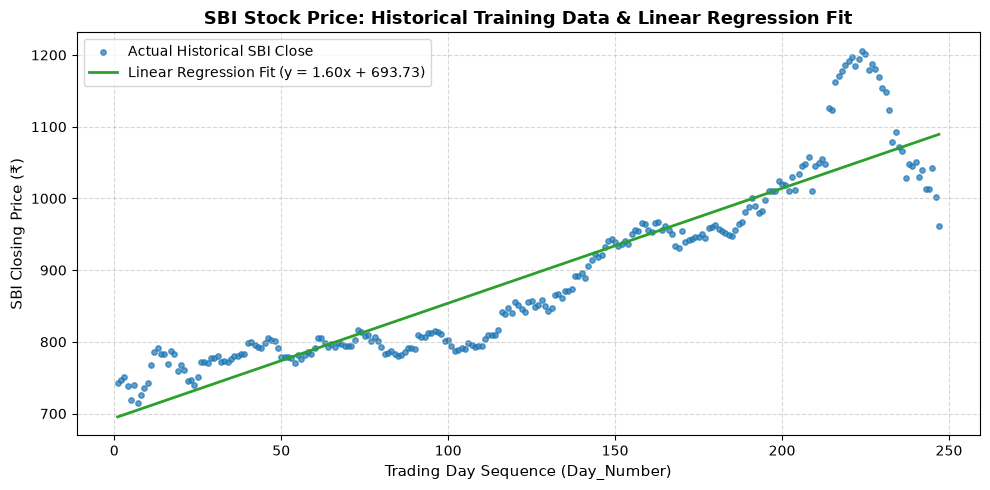

In [6]:
plt.figure(figsize=(10, 5))
plt.scatter(df['Day_Number'], df['Close'], color='#1f77b4', s=15, alpha=0.7, label='Actual Historical SBI Close')
plt.plot(df['Day_Number'], y_pred_hist, color='#2ca02c', linewidth=2, label=f'Linear Regression Fit (y = {slope_m:.2f}x + {intercept_c:.2f})')
plt.title('SBI Stock Price: Historical Training Data & Linear Regression Fit', fontsize=13, fontweight='bold')
plt.xlabel('Trading Day Sequence (Day_Number)', fontsize=11)
plt.ylabel('SBI Closing Price (₹)', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

## 9. Flexible Future Prediction Duration
Set the prediction horizon to any desired number of trading days (e.g. 10, 20, 30, 60, 90, 120).

In [7]:
# Change this number to test any prediction duration
FUTURE_DAYS = 30
print(f'Selected future trading days to predict: {FUTURE_DAYS}')

Selected future trading days to predict: 30


## 10. Future Predicted SBI Prices Table
Generates valid NSE trading dates excluding weekends and NSE holidays, starting from the first trading day after 31 March 2026 (1 April 2026).

In [8]:
# Official NSE Holidays for 2026
NSE_HOLIDAYS_2026 = {
    datetime.date(2026, 4, 3),   # Good Friday
    datetime.date(2026, 4, 14),  # Ambedkar Jayanti
    datetime.date(2026, 5, 1),   # Maharashtra Day
    datetime.date(2026, 5, 28),  # Bakri Id
    datetime.date(2026, 6, 26),  # Muharram
    datetime.date(2026, 8, 28),  # Milad-un-Nabi
    datetime.date(2026, 10, 2),  # Mahatma Gandhi Jayanti
    datetime.date(2026, 10, 20), # Dussehra
    datetime.date(2026, 11, 10), # Diwali Balipratipada
    datetime.date(2026, 11, 24), # Guru Nanak Jayanti
    datetime.date(2026, 12, 25), # Christmas
}

def get_future_trading_dates(start_date, n_days):
    trading_dates = []
    curr = start_date
    while len(trading_dates) < n_days:
        if curr.weekday() < 5 and curr not in NSE_HOLIDAYS_2026:
            trading_dates.append(curr)
        curr += datetime.timedelta(days=1)
    return trading_dates

last_day_num = df['Day_Number'].iloc[-1]
future_dates = get_future_trading_dates(datetime.date(2026, 4, 1), FUTURE_DAYS)
future_day_nums = np.arange(last_day_num + 1, last_day_num + 1 + FUTURE_DAYS)
future_preds = model.predict(pd.DataFrame({'Day_Number': future_day_nums}))

future_df = pd.DataFrame({
    'Future Day': np.arange(1, FUTURE_DAYS + 1),
    'Trading Date': [d.strftime('%Y-%m-%d') for d in future_dates],
    'Day Number': future_day_nums,
    'Predicted SBI Close': [f'₹{p:.2f}' for p in future_preds]
})

future_df

,Future Day,Trading Date,Day Number,Predicted SBI Close
0,1,2026-04-01,248,₹1090.98
1,2,2026-04-02,249,₹1092.59
2,3,2026-04-06,250,₹1094.19
3,4,2026-04-07,251,₹1095.79
4,5,2026-04-08,252,₹1097.39
5,6,2026-04-09,253,₹1098.99
6,7,2026-04-10,254,₹1100.60
7,8,2026-04-13,255,₹1102.20
8,9,2026-04-15,256,₹1103.80
9,10,2026-04-16,257,₹1105.40


## 11. Example Calculation
Using the trained model parameters:
- Slope ($m$) = $1.601846$
- Intercept ($c$) = $693.726286$

For **Future Day 1** (`2026-04-01`), where $x = 248$:
$$\text{Predicted Price} = m \times \text{Day\_Number} + c$$
$$\text{Predicted Price} = (1.601846 \times 248) + 693.726286$$
$$\text{Predicted Price} = 397.257891 + 693.726286 = ₹1090.98$$

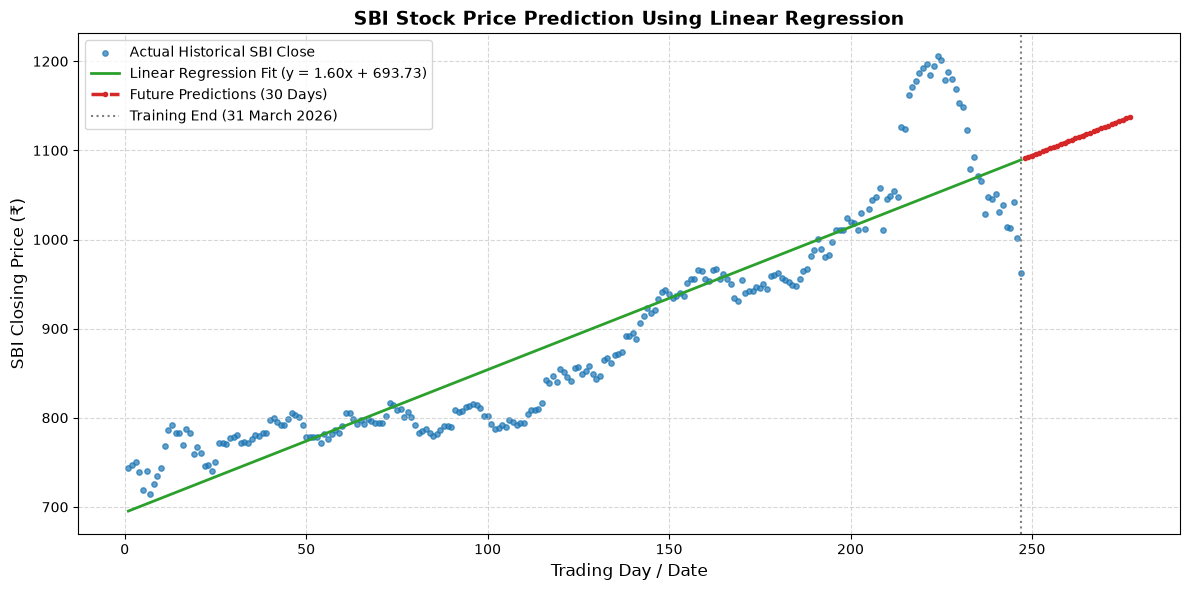

In [9]:
# Combined Plot: Historical Data + Linear Regression Line + Future Predictions
plt.figure(figsize=(12, 6))
plt.scatter(df['Day_Number'], df['Close'], color='#1f77b4', s=15, alpha=0.7, label='Actual Historical SBI Close')
plt.plot(df['Day_Number'], y_pred_hist, color='#2ca02c', linewidth=2, label=f'Linear Regression Fit (y = {slope_m:.2f}x + {intercept_c:.2f})')
plt.plot(future_day_nums, future_preds, color='#d62728', linestyle='--', linewidth=2.5, marker='o', markersize=3, label=f'Future Predictions ({FUTURE_DAYS} Days)')
plt.axvline(x=last_day_num, color='gray', linestyle=':', label='Training End (31 March 2026)')
plt.title('SBI Stock Price Prediction Using Linear Regression', fontsize=14, fontweight='bold')
plt.xlabel('Trading Day / Date', fontsize=12)
plt.ylabel('SBI Closing Price (₹)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='upper left')
plt.tight_layout()
plt.savefig('sbi_stock_prediction_graph.png', dpi=200)
plt.show()

## 12. Conclusion & Important Explanation

### Method Explanation
- **Linear Regression** predicts a numerical continuous value, making it suitable to capture baseline price trajectories over time.
- The model learns the statistical mapping between **Trading Day Number $\rightarrow$ SBI Closing Price** and estimates parameters to fit $y = mx + c$.
- Extrapolating this line across subsequent trading days provides estimated price levels under the assumption of trend continuation.

### Practical Results Summary:
- **Sample Size:** 247 valid trading days (FY 2025–26).
- **Trend (Slope $m$):** +₹1.60 per trading day.
- **Goodness of Fit ($R^2$):** 0.8453 (84.53% of variance captured).
- **Error Metrics:** MAE = ₹36.24, RMSE = ₹48.85.

---
> **Final Warning:**  
> *"These are predictions generated by a Linear Regression model based on historical SBI prices. They are estimates only and are not guaranteed future market prices."*